## Parte 1

In [1]:
!pip install numpy
!pip install matplotlib
!pip install pillow
!git clone https://github.com/kustergabriel/sistemas-e-sinais.git

Cloning into 'sistemas-e-sinais'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 14 (delta 2), reused 14 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 1.69 MiB | 8.70 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [2]:
# Bibliotecas
import math
import numpy as np
import matplotlib.pyplot as plt
import cv2

### Sinal corrompido pelo ruído deve ser representado por x[n] = s[n] + r[n]

In [3]:
N = 1

resultado = np.zeros(200)
s = np.zeros(200)
r = np.zeros(200)

for n in range (0,200):
  s[n] = math.cos(0.8 * n) + 0.3 * math.sin(0.20 * n)
  r[n] = np.random.uniform(-0.3, 0.3, N)

  resultado[n] = s[n]+r[n]

print (resultado)
# resultado é o sinal corrompido que é o sinal de entrada

[ 0.76068575  0.8065416  -0.07692561 -0.68248503 -0.68119918 -0.50548046
  0.24058888  0.84679204  1.14738973  0.82613232  0.36883676 -0.41651005
 -0.97628677 -0.11025542  0.54286313  0.93843489  1.02763037  0.62597322
 -0.0949803  -1.14670176 -1.45023094 -0.62062884 -0.24363051  0.54507975
  0.65555668  0.07121573 -0.36655678 -0.93694715 -1.15376277 -0.51074738
  0.27687288  1.08791306  0.66517023  0.39284525 -0.49163666 -0.70792156
 -0.82358435  0.30354324  0.63446126  1.20433009  1.27033005  0.72261412
 -0.45075658 -0.57629778 -0.76807579 -0.13133387  0.76601122  1.20860653
  0.76775706 -0.03214703 -0.82827786 -1.03187085 -0.70017311 -0.31749781
  0.21030515  0.61180156  0.64120843 -0.57173579 -1.29239169 -1.14328767
 -0.64719591 -0.02909575  0.65757108  1.1422768   0.93832549  0.05936298
 -0.64886248 -0.56190694 -0.27808694  0.64858425  1.11985403  1.35091751
  1.01143498 -0.30764059 -0.59746297 -0.86113123 -0.03439747  0.69558974
  1.06460994  0.67108951  0.4735437  -0.4093709  -0

/tmp/ipykernel_869/2667788697.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[n] = np.random.uniform(-0.3, 0.3, N)


Sinal em amarelo é o sinal Original e o sinal em vermelho é o sinal com Ruido

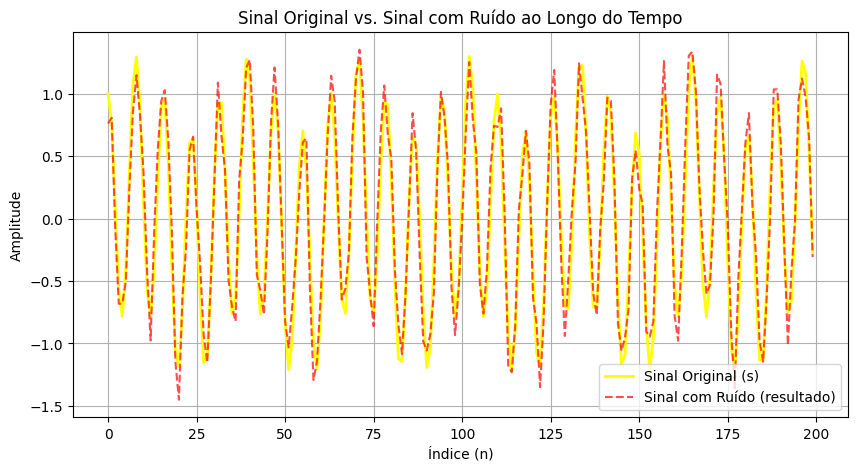

In [4]:
n_values = np.arange(200)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(n_values, s, label='Sinal Original (s)', color='yellow', lw=2)

ax.plot(n_values, resultado, label='Sinal com Ruído (resultado)', color='red', linestyle='--', alpha=0.7)

ax.set_title('Sinal Original vs. Sinal com Ruído ao Longo do Tempo')
ax.set_xlabel('Índice (n)')
ax.set_ylabel('Amplitude')

ax.legend()

ax.grid(True)

plt.show()

### A resposta ao impulso h[n]
#### h[n] = (1 −a)(a)n · u[n].

In [5]:
n = 0

h1 = np.zeros(200)
h2 = np.zeros(200)
h3 = np.zeros(200)

a1 = 0.5
a2 = 0.75
a3 = 0.95

for n in range(0,200):
  h1[n] = (1-a1) * (a1**n)* 1 # como os valores vão de 0 a 200, u[n] >= 0 então vai ser sempre 1

for n in range(0,200):
  h2[n] = (1-a2) * (a2**n)* 1

for n in range(0,200):
  h3[n] = (1-a3) * (a3**n)* 1

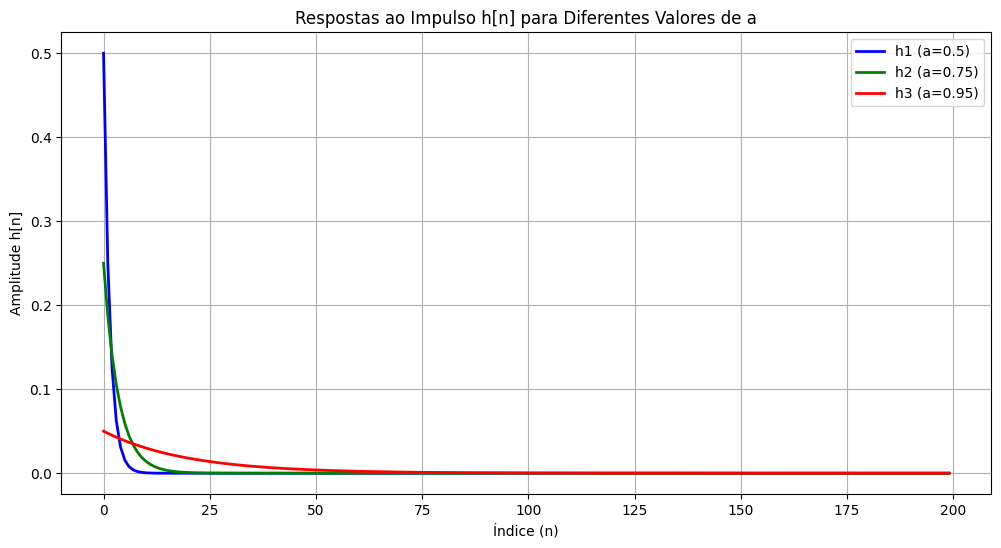

In [6]:
n_values = np.arange(200)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(n_values, h1, label=f'h1 (a={a1})', color='blue', lw=2)

ax.plot(n_values, h2, label=f'h2 (a={a2})', color='green', lw=2)

ax.plot(n_values, h3, label=f'h3 (a={a3})', color='red', lw=2)

ax.set_title('Respostas ao Impulso h[n] para Diferentes Valores de a')
ax.set_xlabel('Índice (n)')
ax.set_ylabel('Amplitude h[n]')

ax.legend()

ax.grid(True)

plt.show()

### Convolução em tempo discreto
#### c[n] = x[n] ∗ h[n]

In [7]:
def convol(x, h):
  len_x = len(x)
  len_h = len(h)

  len_c = len_x + len_h - 1

  c = np.zeros(len_c)

  for n in range(len_c):
    for k in range(len_x):
      if 0 <= n - k < len_h:
        c[n] += x[k] * h[n - k]

  return c

In [8]:
c1 = convol(resultado, h1)

c2 = convol(resultado, h2)

c3 = convol(resultado, h3)


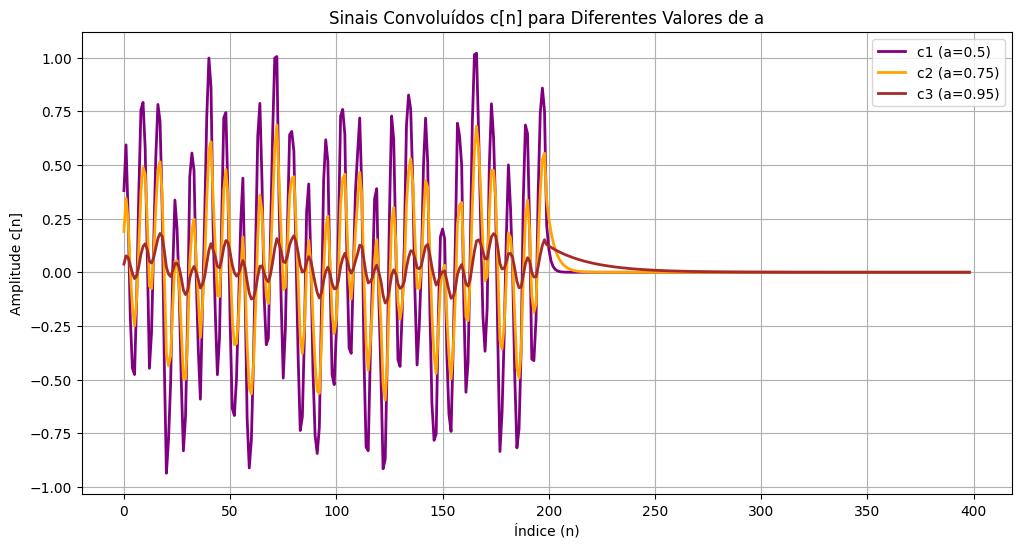

In [9]:
n_values = np.arange(len(c1))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(n_values, c1, label=f'c1 (a={a1})', color='purple', lw=2)

ax.plot(n_values, c2, label=f'c2 (a={a2})', color='orange', lw=2)

ax.plot(n_values, c3, label=f'c3 (a={a3})', color='brown', lw=2)

ax.set_title('Sinais Convoluídos c[n] para Diferentes Valores de a')
ax.set_xlabel('Índice (n)')
ax.set_ylabel('Amplitude c[n]')

ax.legend()

ax.grid(True)

plt.show()

## Parte 2

Utilizei como base para aprender o código da convolução 2D esse artigo no Medium: https://medium.com/@er_95882/convolution-image-filters-cnns-and-examples-in-python-pytorch-bd3f3ac5df9c

A diferença do código para a equação mostrada, é que o somatório não irá até o infinito, e sim da largura e altura minima até a maxima da imagem.

Acredito que depois de entender isso foi fácil de entender e passar para o código.

Outra diferença é a subtração da altura e largura do kernel, isso ocorre por que nós não podemos calcular o kernel onde não existe imagem. Imagine que a largura da imagem é 100 px e o kernel é 3, só é possivel calcular o kernel até 97 + 1. E o mesmo se aplica para a altura!

c[x, y] = I[x, y] ∗ K[x, y]

I[x, y] -> Imagem

---

K[x, y] -> Resposta ao impulso

---

x e y representam as coordenadas de cada pixel da imagem

---

c[x, y] representa o resultado da operação de
convolução 2D

In [25]:
def convol2d(image, kernel):

  image_height, image_width = image.shape
  kernel_height, kernel_width = kernel.shape

  print (kernel.shape)

  output_height = image_height - kernel_height + 1
  output_width = image_width - kernel_width + 1

  output = np.zeros((output_height, output_width))
  # image
  for i in range(output_height):
    for j in range(output_width):
      c_x_y = 0
      # kernel
      for kh in range(kernel_height):
        for kw in range(kernel_width):

          c_x_y += image[i + kh, j + kw] * kernel[kh, kw]

      output[i, j] = c_x_y

  return output

Tive dificuldade para pensar em uma forma do colab não SUMIR com a minha foto, como solução eu clonei o meu repositório github que tinha a foto, e ai com isso eu busquei pelo diretório da foto.

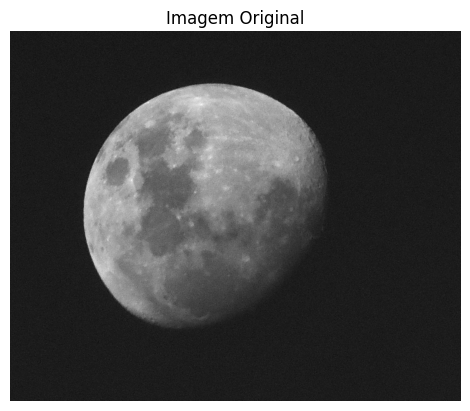

In [21]:
img = cv2.imread("/content/sistemas-e-sinais/files/DSCN2957 (Edited).JPG")

imagem = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(imagem, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')
plt.show()


(3, 3)


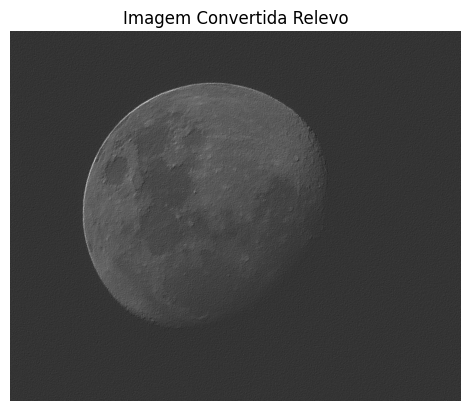

In [26]:
# criação dos filtros de acordo com o enunciado
k_relevo = np.array([ [-2, -1, 0],
                      [-1, 1, 1],
                      [ 0, 1, 2] ])

k_bordas = np.array([ [-1, -2, -1],
                      [0, 0, 0],
                      [1, 2, 1] ])

imagem_convertida_relevo_pequena = convol2d (imagem, k_relevo)

plt.imshow(imagem_convertida_relevo_pequena, cmap='gray')
plt.title('Imagem Convertida Relevo')
plt.axis('off')
plt.show()

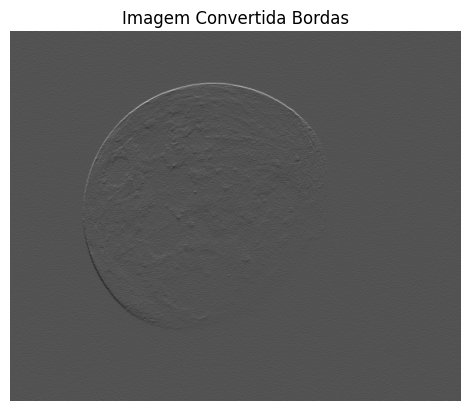

In [19]:
imagem_convertida_bordas = convol2d (imagem, k_bordas)

plt.imshow(imagem_convertida_bordas, cmap='gray')
plt.title('Imagem Convertida Bordas')
plt.axis('off')
plt.show()